# Simulation for Section 4.2 (monte carlo experiments for nonlinear models)

## Import Required Libraries

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
import torch
import warnings
import numpy as np
import traceback

from argparse import Namespace
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from scipy.stats import t, norm
from utl import (gen_data_betamixing, QtES_LP)

from quantes.nonlinear import FNN, LocPoly
warnings.filterwarnings('ignore', category=RuntimeWarning)
print(torch.cuda.is_available())


False


## Setup

In [2]:
args = Namespace(
    tau=0.1,
    dof=2.25,
    scale_norm=1,
    scale_t=1/3,
    n_train = np.array([2**11 + i * 1024 for i in range(11)]),
    h=64,
    batch_size=128,
    val_pct=.1,
    activation='relu',
    optimizer='adam',
    lr=0.0001,
    max_epochs=400,
    patience=30,
    seed=2024,
    device = 'cuda'
)

# Functions

## Neural network regression

In [3]:
params = {'batch_size' : args.batch_size, 
          'val_pct' : args.val_pct, 
          'width': [args.h, 2*args.h, 2*args.h, args.h],
          'activation' : args.activation, 
          'optimizer' : args.optimizer, 
          'lr' : args.lr,
          'n_epochs' : args.max_epochs,
          'early_stopping_patience' : args.patience}


def get_device(m):
    if str(args.device).startswith('cuda') and torch.cuda.is_available():
        n_gpus = torch.cuda.device_count()
        if n_gpus > 0:
            return f'cuda:{m % n_gpus}'
    return 'cpu'

def nn_sequence(m, error='normal',  exponent=.2, type = None, v=0.5):
    device = get_device(m)
    err1, err2, err3, err4 = [], [], [], []
    err_scale = args.scale_norm if error == 'normal' else args.scale_t
    X_all, Y_all, Qt, ES = gen_data_betamixing(
            n=args.n_train[-1], type=type, err_dist=error, df=args.dof,
            err_scale=err_scale, random_state=m, v=v)
    X = X_all[:args.n_train[-1], :]
    Y = Y_all[:args.n_train[-1]]
    X_Qt = Qt[:args.n_train[-1]]
    X_test = X_all[-1024:, :]
    testes = ES[-1024:]

    for n in args.n_train:
        n = int(n)
        x, y = X[:n], Y[:n]
        torch.manual_seed(1)
        nn1 = FNN(x, y)
        nn1.qt(tau=args.tau, options=params, device = device)
        fit_q = nn1.predict(x)
        Z = np.minimum(y - fit_q, 0) / args.tau
        huber_param = 0.25*np.std(Z) * (n/(np.log(n)))**exponent

        nn2 = FNN(x, Z + fit_q)
        torch.manual_seed(2)
        nn2.ls(options=params, robust=False, device = device)
        err1.append(np.mean((testes - nn2.predict(X_test))**2))

        torch.manual_seed(2)
        nn2.ls(options=params, robust=True, c=huber_param, device = device)
        err2.append(np.mean((testes - nn2.predict(X_test))**2))

        oracle_q = X_Qt[:n]
        oracle_Z = np.minimum(y - oracle_q, 0) / args.tau 
        oracle_huber = 0.25*np.std(oracle_Z) * (n/(np.log(n)))**exponent

        nn3 = FNN(x, oracle_Z + oracle_q)
        torch.manual_seed(3)
        nn3.ls(options=params, robust=False, device = device)
        err3.append(np.mean((testes - nn3.predict(X_test))**2))

        torch.manual_seed(3)
        nn3.ls(options=params, robust=True, c=oracle_huber, device = device)
        err4.append(np.mean((testes - nn3.predict(X_test))**2))

    return np.c_[err1, err2, err3, err4]


def nn_fix(m, n=4096, error='normal', exponent=.2, type = None, v=0.5, robust = False):
    device = get_device(m)
    err = []
    err_scale = args.scale_norm if error == 'normal' else args.scale_t
    X_all, Y_all, Qt, ES = gen_data_betamixing(
            n=n, type=type, err_dist=error, df=args.dof,
            err_scale=err_scale, random_state=m, v=v)
    X = X_all[:n, :]
    Y = Y_all[:n]
    X_test = X_all[-1024:, :]
    testes = ES[-1024:]

    nn1 = FNN(X, Y)
    torch.manual_seed(0)
    nn1.qt(tau=args.tau, options=params, device = device)
    fit_q = nn1.predict(X)
    Z = np.minimum(Y - fit_q, 0)/args.tau
    huber_param = 0.25*np.std(Z) * (n/np.log(n))**exponent
    
    nn2 = FNN(X, Z + fit_q)
    torch.manual_seed(1)
    nn2 = FNN(X, Z + fit_q)
    nn2.ls(options=params, robust=False, device = device)
    err.append(np.mean((testes - nn2.predict(X_test))**2))
    if robust:
        torch.manual_seed(1)
        nn2.ls(options=params, robust=True, c=huber_param, device = device)
        err.append(np.mean((testes - nn2.predict(X_test))**2))

    return np.array(err)

def safe_nn_fix(m, n=4096, error='normal', exponent=.2, type = None, v=0.5, robust = False):
    try:
        return nn_fix(m, n, error, exponent, type, v, robust)
    except:
        print('Error in nn_fix')
        return np.array([np.nan,np.nan])

## Local linear regression

In [4]:
bw_q = np.linspace(0.1, 0.9, 20)
bw_e = np.linspace(0.25, 1.5, 20)

def ll_sequence(m, error='normal', type = 'iid', v=0.5):
    err = []
    n_all = int(args.n_train[-1])
    err_scale = args.scale_norm if error == 'normal' else args.scale_t
    X_all, Y_all, Qt, ES = gen_data_betamixing(
            n=n_all, type=type, err_dist=error, df=args.dof,
            err_scale=err_scale, random_state=m, v=v)
    X = X_all[:n_all, :]
    Y = Y_all[:n_all]
    X_test = X_all[-1024:, :]
    testes = ES[-1024:]
    
    for n in args.n_train:
        n = int(n)
        x, y = X[:n], Y[:n]

        n_total = n
        n_val = int(params['val_pct'] * n_total)
    
        train_idx = list(range(0, n_total - n_val))
        val_idx = list(range(n_total - n_val, n_total))
        
        try:
            tuning = QtES_LP(x[train_idx], y[train_idx], x[val_idx], y[val_idx], args.tau, 
                         norm.pdf, bw_q, 1, norm.pdf, bw_e, 1)
            lp = LocPoly(x, y, kernel=norm.pdf)
            fit_q = lp.qt_predict(x0=x, tau=args.tau, bw=tuning['bw_q'], degree=1)
            lp_e = LocPoly(x, np.minimum(y - fit_q, 0) / args.tau + fit_q, kernel=norm.pdf)
            pred_e = lp_e.ls_predict(x0=X_test, bw=tuning['bw_e'], degree=1)
            err.append(np.mean((testes - pred_e)**2))
        except Exception as e:
            err.append(np.inf)
    
    return np.array(err) # shape: (len(n_train),)


def ll_fix(m, n=4096, error='normal', type = 'iid', v=0.5):
    err_scale = args.scale_norm if error == 'normal' else args.scale_t
    X_all, Y_all, Qt, ES = gen_data_betamixing(
            n=n, type=type, err_dist=error, df=args.dof,
            err_scale=err_scale, random_state=m, v=v)
    X = X_all[:n, :]
    Y = Y_all[:n]
    X_test = X_all[-1024:, :]
    testes = ES[-1024:]
    
    n_total = n
    n_val = int(params['val_pct'] * n_total)

    train_idx = list(range(0, n_total - n_val))
    val_idx = list(range(n_total - n_val, n_total))

    tuning = QtES_LP(X[train_idx], Y[train_idx], 
                     X[val_idx], Y[val_idx], args.tau,
                     norm.pdf, bw_q, 1,
                     norm.pdf, bw_e, 1)
    lp = LocPoly(X, Y, kernel=norm.pdf)
    fit_q = lp.qt_predict(X, tau=args.tau, bw=tuning['bw_q'], degree=1)
    surrogate_Y = np.minimum(Y - fit_q, 0)/args.tau + fit_q
    lp_e = LocPoly(X, surrogate_Y, kernel=norm.pdf)
    fit_e = lp_e.ls_predict(X_test, bw=tuning['bw_e'], degree=1)

    return np.mean((testes - fit_e)**2)

def safe_ll_fix(m, n=4096, error='normal', type = 'iid', v=0.5):
    try:
        return ll_fix(m, n, error, type, v)
    except:
        print('Error in ll_fix')
        return np.nan

In [5]:
# Define a function to remove NaN values and save to a CSV file.
import pandas as pd
def save_to_csv(data, filename):
    # Check data dimensions
    if data.ndim == 2:
        # Filter out rows containing NaN
        data_cleaned = data[~np.isnan(data).any(axis=1)]
    elif data.ndim == 1:
        # Filter out NaN values
        data_cleaned = data[~np.isnan(data)]
    else:
        raise ValueError("Data dimensions are incorrect. Please provide a 1D or 2D array.")

    # Save the result as a DataFrame and export to a CSV file
    df = pd.DataFrame(data_cleaned)
    df.to_csv(filename, index=False, header=False)
    print(f"Data has been saved to {filename}")


# Begin Simulations

In [ ]:
cores = 250
M = 500

sim_list = ['EXPAR_v1', 'FAR_v1', 'SIM_v1']
for sim in sim_list:
    try: 
        # fix_nn_n = np.array(Parallel(n_jobs=cores)(delayed(nn_fix)(m, 8192, 't', 0.2, sim, v=0.5, robust= True) for m in tqdm(range(M))))
        # print(np.nanmean(np.where(np.isinf(fix_nn_n), np.nan, fix_nn_n), axis=0))
        fix_ll_n = np.array(Parallel(n_jobs=cores)(delayed(safe_ll_fix)(m, 8192, 't', sim, v=0.5) for m in tqdm(range(M))))
        print(sim, np.nanmean(fix_ll_n),np.nanmean(fix_nn_n, axis = 0))
        result = np.column_stack((fix_ll_n, fix_nn_n))
        save_to_csv(result, './res_nonlinear/fix_n_t_'+sim+'_all.csv')
    except Exception as e:
        error_message = f"程序运行出错:\n{traceback.format_exc()}"
        print(error_message)

    try: 
        fix_nn_n = np.array(Parallel(n_jobs=cores)(delayed(nn_fix)(m, 4096, 'normal', 0.2, sim, v=0.5, robust= True) for m in tqdm(range(M))))
        print(np.nanmean(np.where(np.isinf(fix_nn_n), np.nan, fix_nn_n), axis=0))
        fix_ll_n = np.array(Parallel(n_jobs=cores)(delayed(safe_ll_fix)(m, 4096, 'normal', sim, v=0.5) for m in tqdm(range(M))))
        print(sim, np.nanmean(fix_ll_n),np.nanmean(fix_nn_n, axis = 0))
        result = np.column_stack((fix_ll_n, fix_nn_n))
        save_to_csv(result, './res_nonlinear/fix_n_normal_'+sim+'_all.csv')
    except Exception as e:
        error_message = f"程序运行出错:\n{traceback.format_exc()}"
        print(error_message)

## Summary and plot the results

In [7]:
from pathlib import Path
import pandas as pd


COLUMNS = ["LLES", "DES", "DES-H"]
def summarize_result_type(
    result_type,
    version="v1",
    res_dir="./res_nonlinear",
    ddof=1,
    decimals=4,
):
    """
    Calculate the mean, standard deviation, and sample size for each method in the t and normal data.
    """
    result_type = result_type.upper()
    res_dir = Path(res_dir)

    summaries = []

    for condition in ["t", "normal"]:
        input_path = (
            res_dir
            / f"fix_n_{condition}_{result_type}_{version}_all.csv"
        )

        if not input_path.exists():
            raise FileNotFoundError(f"找不到文件：{input_path}")

        df = pd.read_csv(input_path, header=None)

        if df.shape[1] != len(COLUMNS):
            raise ValueError(
                f"{input_path} should have {len(COLUMNS)} columns,"
                f"but actually has {df.shape[1]} columns"
            )

        df.columns = COLUMNS

        # Convert to numeric values, clean up inf, -inf, and NaN
        df = df.apply(pd.to_numeric, errors="coerce")
        df = df.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

        # Calculate the statistics for each method
        summary = pd.DataFrame({
            "condition": condition,
            "method": COLUMNS,
            "mean": df.mean(axis=0).to_numpy(),
            "std": df.std(axis=0, ddof=ddof).to_numpy()
        })

        summaries.append(summary)

    result = pd.concat(summaries, ignore_index=True)
    result[["mean", "std"]] = result[["mean", "std"]].round(decimals)
    return result

In [8]:
expar_summary = summarize_result_type("EXPAR")
print(expar_summary)

  condition method    mean     std
0         t   LLES  0.1143  0.0864
1         t    DES  0.0721  0.0408
2         t  DES-H  0.0396  0.0230
3    normal   LLES  0.1284  0.0543
4    normal    DES  0.1138  0.0512
5    normal  DES-H  0.0909  0.0382


In [9]:
far_summary = summarize_result_type("FAR")
print(far_summary)

  condition method    mean     std
0         t   LLES  0.6133  1.0275
1         t    DES  0.3404  0.2254
2         t  DES-H  0.2302  0.2126
3    normal   LLES  0.5914  0.1671
4    normal    DES  0.4002  0.1851
5    normal  DES-H  0.3192  0.0998


In [10]:
sim_summary = summarize_result_type("SIM")
print(sim_summary)

  condition method    mean     std
0         t   LLES  0.0395  0.0256
1         t    DES  0.0110  0.0052
2         t  DES-H  0.0061  0.0034
3    normal   LLES  0.0464  0.0173
4    normal    DES  0.0181  0.0067
5    normal  DES-H  0.0131  0.0037


In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
COLUMNS = ["LLES", "DES", "DES-H"]
COLORS = ["lightcoral", "lightskyblue", "lightgreen"]

def read_result_csv(file_path):
    """Read and clean the result data."""
    df = pd.read_csv(file_path, header=None)

    # Check the number of columns
    if df.shape[1] != len(COLUMNS):
        raise ValueError(
            f"{file_path} 应有 {len(COLUMNS)} 列，实际有 {df.shape[1]} 列"
        )

    df.columns = COLUMNS

    # Convert to numeric values, clean up inf, -inf, and NaN
    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.replace([np.inf, -np.inf], np.nan).dropna(axis=0)
    return df

def draw_boxplot(
    df,
    output_path,
    title=None,
    ylim=None,
    show=True,
    flier_size=1,
):
    """Draw and save a single box plot."""
    sns.set_style("darkgrid")

    fig, ax = plt.subplots(figsize=(6.4, 4.8))

    boxplot = ax.boxplot(
        [df[column].to_numpy() for column in COLUMNS],
        widths=0.3,
        patch_artist=True,
        tick_labels=COLUMNS,
        flierprops={
            "marker": "o",
            "markersize": flier_size,
        },
    )
    # color
    for patch, color in zip(boxplot["boxes"], COLORS):
        patch.set_facecolor(color)
        patch.set_linewidth(0.5)

    for median in boxplot["medians"]:
        median.set_color("black")
        median.set_linewidth(1)

    ax.tick_params(axis="x", labelsize=13)
    ax.tick_params(axis="y", labelsize=13)

    if title is not None:
        ax.set_title(title, fontsize=14)

    if ylim is not None:
        ax.set_ylim(*ylim)

    fig.tight_layout()
    fig.savefig(output_path, format="pdf", bbox_inches="tight")

    if show:
        plt.show()
    plt.close(fig)


def plot_result_type(
    result_type,
    version="v1",
    res_dir="./res_nonlinear",
    output_dir="./res_nonlinear",
    show=True,
):
    """
    Draw a box plot for a certain type of t and normal.
    """
    result_type = result_type.upper()

    valid_types = {"EXPAR", "FAR", "SIM"}
    if result_type not in valid_types:
        raise ValueError(
            f"result_type must be one of {sorted(valid_types)},"
            f"current input is {result_type!r}"
        )

    res_dir = Path(res_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    ylim_config = {
        ("FAR", "t"): (0, 4),
        # ("FAR", "normal"): (xx, xx),
        # ("EXPAR", "t"): (xx, xx),
        # ("SIM", "t"): (xx, xx),
        # ("SIM", "normal"): (xx, xx),
    }

    conditions = {
        "t": "t",
        "normal": "n",
    }

    for input_condition, output_condition in conditions.items():
        input_path = (
            res_dir
            / f"fix_n_{input_condition}_{result_type}_{version}_all.csv"
        )

        output_path = (
            output_dir
            / f"boxplot_{result_type.lower()}_{output_condition}.pdf"
        )

        if not input_path.exists():
            raise FileNotFoundError(f"Data file not found: {input_path}")

        df = read_result_csv(input_path)

        draw_boxplot(
            df=df,
            output_path=output_path,
            title=None,
            ylim=ylim_config.get((result_type, input_condition)),
            show=show,
            flier_size=1,
        )

        print(f"Generated:{output_path}")

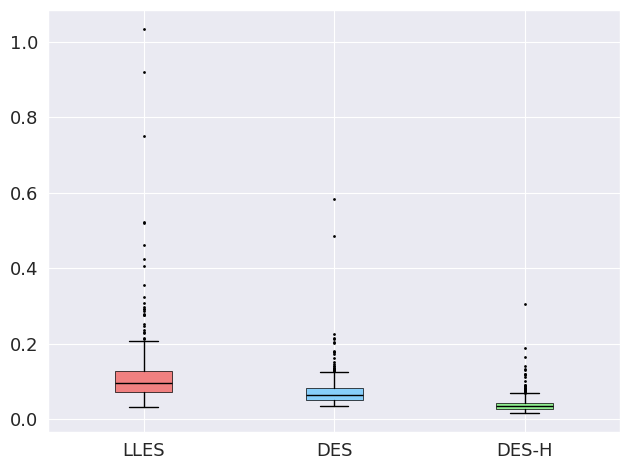

Generated:res_nonlinear/boxplot_expar_t.pdf


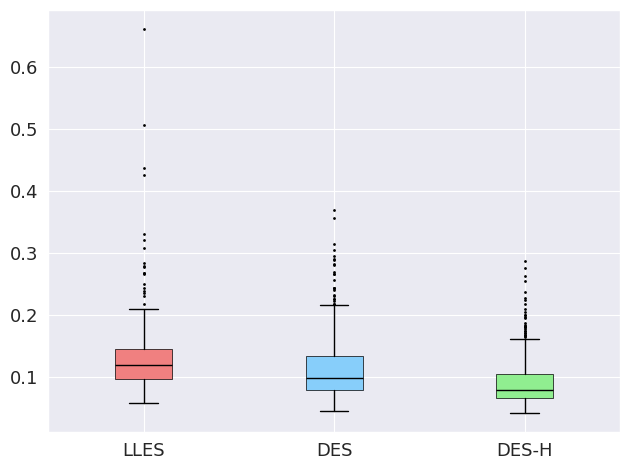

Generated:res_nonlinear/boxplot_expar_n.pdf


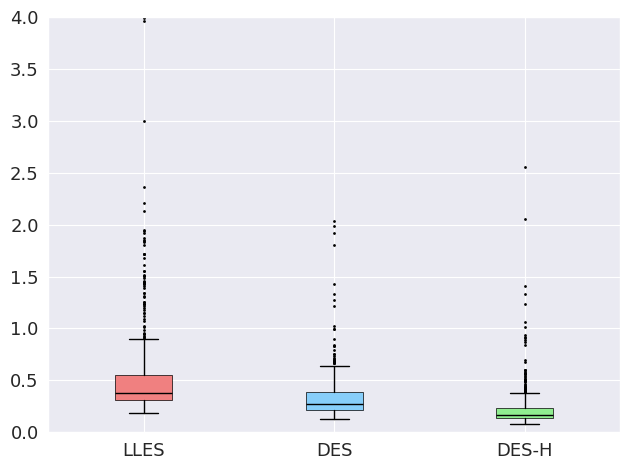

Generated:res_nonlinear/boxplot_far_t.pdf


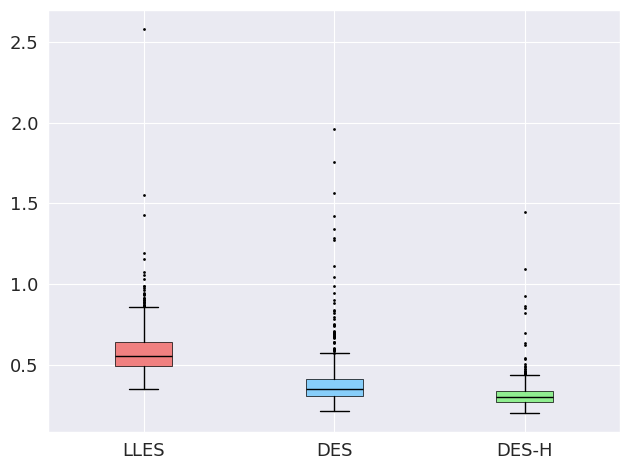

Generated:res_nonlinear/boxplot_far_n.pdf


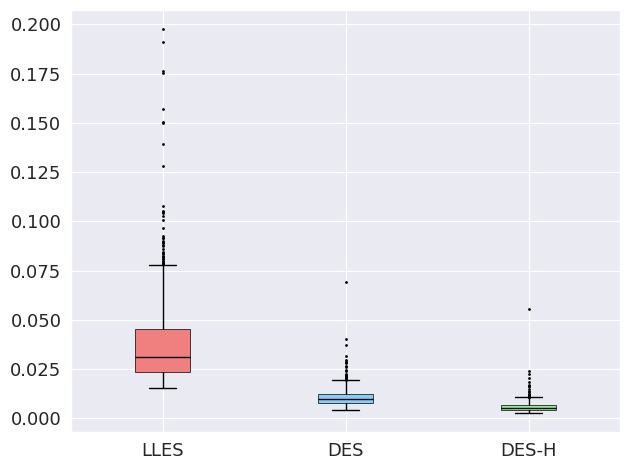

Generated:res_nonlinear/boxplot_sim_t.pdf


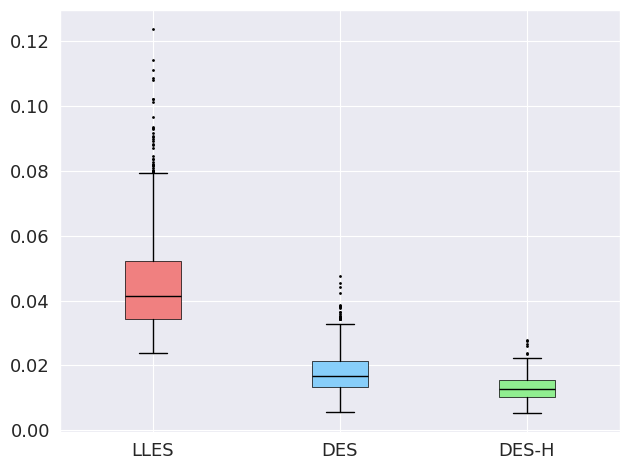

Generated:res_nonlinear/boxplot_sim_n.pdf


In [12]:
plot_result_type("EXPAR")
plot_result_type("FAR")
plot_result_type("SIM")

In [ ]:
cores = 250
M = 200

sim_list = ['EXPAR_v1','FAR_v1',"SIM_v1"]

for sim in sim_list:
    try: 
        fix_nn_n = np.array(Parallel(n_jobs=cores)(delayed(nn_sequence)(m, 't', 0.2, sim, v=0.5) for m in tqdm(range(M))))
        print(np.nanmean(np.where(np.isinf(fix_nn_n), np.nan, fix_nn_n), axis=0))
        fix_ll_n = np.array(Parallel(n_jobs=cores)(delayed(ll_sequence)(m,'t', sim, v=0.5) for m in tqdm(range(M))))
        fix_ll_n_expanded = np.expand_dims(fix_ll_n, axis=2)
        result = np.concatenate((fix_ll_n_expanded, fix_nn_n), axis=2)
        print(np.nanmean(np.where(np.isinf(result), np.nan, result), axis=0))
        np.savez('./res_nolinear/fix_nn_n_t_'+sim+'_all.npz', result=result)
    except Exception as e:
        error_message = f"程序运行出错:\n{traceback.format_exc()}"
        print(error_message)
    
    try:
        fix_nn_n = np.array(Parallel(n_jobs=cores)(delayed(nn_sequence)(m,'normal', 0.2, sim, v=0.5) for m in tqdm(range(M))))
        print(np.nanmean(np.where(np.isinf(fix_nn_n), np.nan, fix_nn_n), axis=0))
        fix_ll_n = np.array(Parallel(n_jobs=cores)(delayed(ll_sequence)(m,'normal', sim, v=0.5) for m in tqdm(range(M))))
        fix_ll_n_expanded = np.expand_dims(fix_ll_n, axis=2)
        result = np.concatenate((fix_ll_n_expanded, fix_nn_n), axis=2)
        print(np.nanmean(np.where(np.isinf(result), np.nan, result), axis=0))
        np.savez('./res_nolinear/fix_nn_n_normal_'+sim+'_all.npz', result=result)
    except Exception as e:
        error_message = f"程序运行出错:\n{traceback.format_exc()}"
        print(error_message)

In [6]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def trim_large_values(
    result,
    columns=(0,),
    rule="iqr",
    iqr_k=3.0,
    quantile=0.99,
    fixed_upper=None,
):
    """
    Since the results of LLES contain some extreme values, this function is used to remove certain outliers to better present the findings.

    For each sample size, delete the extreme maximum value in the specified method.

    result shape should be:
        (Number of repeated experiments, sample size quantity, number of methods)
    columns:
        The method column to be processed in the original result.
        (0,) indicates that only LLES will be processed.。
    rule:
        "iqr"      : Remove values greater than Q3 + iqr_k * IQR
        "quantile" : Remove values above the specified quantile.
        "fixed"    : Remove values above the specified fixed upper bound.
    """
    result = np.asarray(result, dtype=float).copy()
    result[~np.isfinite(result)] = np.nan

    if result.ndim != 3:
        raise ValueError(
            "result should be a 3D array:"
            "(Number of repeated experiments, sample size quantity, number of methods)"
        )

    removed_counts = {}

    for column in columns:
        values = result[:, :, column]

        if rule == "iqr":
            q1 = np.nanpercentile(values, 25, axis=0)
            q3 = np.nanpercentile(values, 75, axis=0)
            upper_bound = q3 + iqr_k * (q3 - q1)

        elif rule == "quantile":
            upper_bound = np.nanquantile(
                values,
                quantile,
                axis=0,
            )

        elif rule == "fixed":
            if fixed_upper is None:
                raise ValueError(
                    "rule='fixed' with no fixed_upper"
                )
            upper_bound = np.full(
                values.shape[1],
                fixed_upper,
            )

        else:
            raise ValueError(
                "rule should be 'iqr', 'quantile', or 'fixed'"
            )

        outlier_mask = values > upper_bound[None, :]
        result[:, :, column] = np.where(
            outlier_mask,
            np.nan,
            values,
        )
        removed_counts[column] = outlier_mask.sum(axis=0)

    return result, removed_counts


def plot_sequence(
    sim,
    condition="t",
    res_dir="./res_nonlinear",
    output_dir="./res_nonlinear",
    selected_columns=(0, 1, 2, 3, 4),
    methods=("LLES", "DES", "DES-H", "oracle DES", "oracle DES-H"),
    sample_size_min=2048,
    sample_size_max=12288,
    legend = False,
    show=True,
):
    """
    Read the NPZ results and plot the MSPE curves under different sample sizes.

    Parameters
    ----------
    sim : str
        Experiment name, e.g., "AAR_v1", "EXPAR_v1".
    condition : str
        Data type, e.g., "t" or "normal".
    res_dir : str
        Directory where NPZ files are located.
    output_dir : str
        Directory for PDF output.
    selected_columns : tuple
        Which methods to select from the last dimension of result.
    methods : tuple
        Names of the selected methods.
    sample_size_min, sample_size_max : int
        Range of sample sizes.
    show : bool
        Whether to display the image.

    Returns
    -------
    result_mean : np.ndarray
        Cleaned and mean values.
    """
    if len(selected_columns) != len(methods):
        raise ValueError(
            "selected_columns 与 methods 的长度必须相同："
            f"{len(selected_columns)} != {len(methods)}"
        )

    res_dir = Path(res_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    input_path = res_dir / f"fix_nn_n_{condition}_{sim}_all.npz"

    if not input_path.exists():
        raise FileNotFoundError(f"could not find file: {input_path}")

    with np.load(input_path) as data:
        result_loaded = data["result"]

    clean_result, removed_counts = trim_large_values(
        result_loaded,
        columns=(0,),   # 只处理 LLES
        rule="iqr",
        iqr_k=3.0,
    )
    result_mean = np.nanmean(clean_result, axis=0)
    result_mean = result_mean[:, selected_columns]

    sample_sizes = np.linspace(
        sample_size_min,
        sample_size_max,
        result_mean.shape[0],
        dtype=int,
    )

    sns.set_style("darkgrid")

    markers = ["o", "^", "d", "x", "s", "v", "*"]

    fig, ax = plt.subplots(figsize=(8, 4))

    for index, method in enumerate(methods):
        ax.plot(
            sample_sizes,
            result_mean[:, index],
            label=method,
            marker=markers[index % len(markers)],
            markersize=6,
            linewidth=1.5,
        )

    ax.set_xlabel("Sample size", fontsize=13)
    ax.set_ylabel("MSPE", fontsize=13)
    ax.tick_params(axis="both", labelsize=13)

    if legend:
        ax.legend(fontsize=13)

    fig.tight_layout()

    short_name = sim.split("_")[0].lower()
    condition_name = "n" if condition == "normal" else condition

    output_path = (
        output_dir
        / f"plots_of_sequence_{short_name}_{condition_name}.pdf"
    )

    fig.savefig(
        output_path,
        bbox_inches="tight",
        format="pdf",
    )

    if show:
        plt.show()

    plt.close(fig)

    print(f"read file: {input_path}")
    print(f"image saved: {output_path}")

    return result_mean

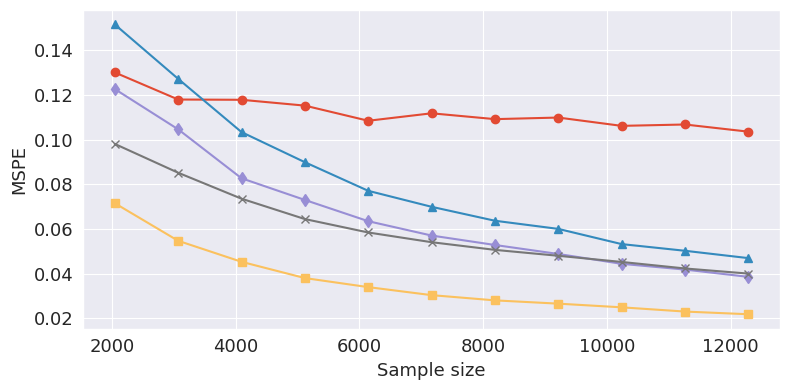

read file: res_nonlinear/fix_nn_n_normal_EXPAR_v1_all.npz
image saved: res_nonlinear/plots_of_sequence_expar_n.pdf


array([[0.13009204, 0.1515809 , 0.12265085, 0.09807416, 0.07150738],
       [0.11796893, 0.1272268 , 0.10461785, 0.08517104, 0.05468744],
       [0.11785086, 0.10338264, 0.08269931, 0.07354635, 0.04527612],
       [0.11524088, 0.08989327, 0.07298719, 0.0644264 , 0.03799414],
       [0.10845869, 0.07707666, 0.06347274, 0.0584185 , 0.03394449],
       [0.11180075, 0.069921  , 0.05704398, 0.05406375, 0.03035073],
       [0.10918709, 0.06367227, 0.05281471, 0.05062554, 0.02800851],
       [0.10989523, 0.0600253 , 0.04879121, 0.04798194, 0.02653933],
       [0.10617222, 0.05321435, 0.04437341, 0.04521651, 0.02489276],
       [0.10678608, 0.05022088, 0.0418063 , 0.04229917, 0.02299497],
       [0.10357889, 0.04693642, 0.03853565, 0.0399989 , 0.02179807]])

In [7]:
plot_sequence("EXPAR_v1", condition="normal")

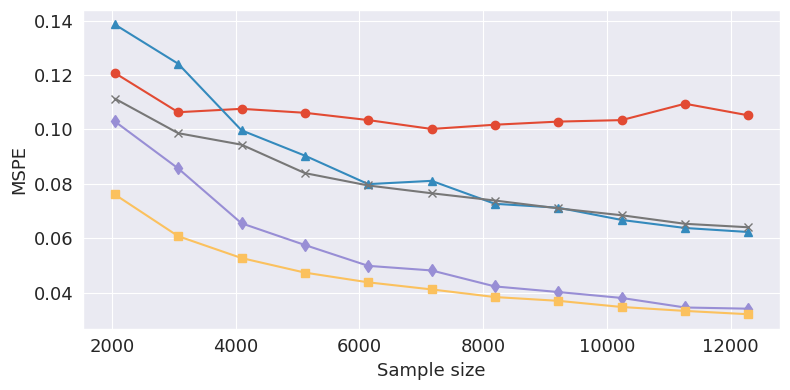

read file: res_nonlinear/fix_nn_n_t_EXPAR_v1_all.npz
image saved: res_nonlinear/plots_of_sequence_expar_t.pdf


array([[0.12075395, 0.13857278, 0.10295659, 0.11134226, 0.07611536],
       [0.10634019, 0.12414854, 0.08567912, 0.09863569, 0.06079129],
       [0.10758242, 0.09968357, 0.06552616, 0.09441258, 0.05275299],
       [0.10612541, 0.09038228, 0.05754954, 0.08396613, 0.04740523],
       [0.10345289, 0.07991602, 0.04989037, 0.07941915, 0.0438323 ],
       [0.1001857 , 0.08112323, 0.04820292, 0.07656329, 0.04122819],
       [0.10174758, 0.07268626, 0.04233102, 0.07389052, 0.03842795],
       [0.10289143, 0.07125807, 0.04027219, 0.07101273, 0.03704017],
       [0.10343869, 0.06675723, 0.03810075, 0.06848279, 0.03477853],
       [0.10945876, 0.06380524, 0.03459385, 0.06534078, 0.03333076],
       [0.10519074, 0.06232406, 0.03414698, 0.06406602, 0.03211302]])

In [8]:
plot_sequence("EXPAR_v1", condition="t")

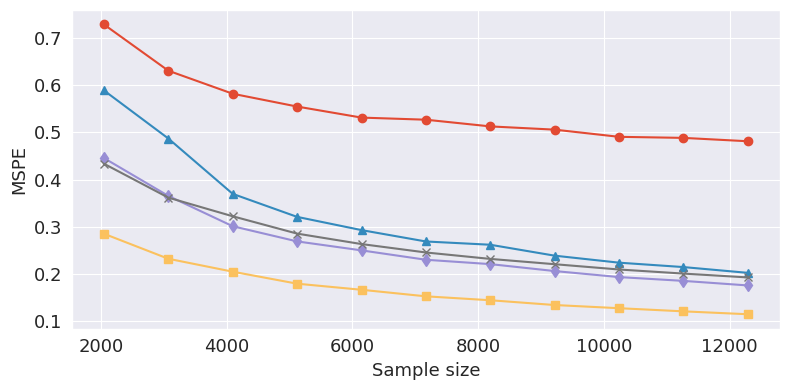

read file: res_nonlinear/fix_nn_n_normal_FAR_v1_all.npz
image saved: res_nonlinear/plots_of_sequence_far_n.pdf


array([[0.72931537, 0.58922402, 0.44561142, 0.43358272, 0.28486484],
       [0.63113491, 0.48709792, 0.36523318, 0.36158847, 0.2317535 ],
       [0.58221398, 0.36955312, 0.30084923, 0.32199552, 0.20432201],
       [0.55502378, 0.3207288 , 0.26863744, 0.28518276, 0.17882607],
       [0.53157377, 0.29263047, 0.24957745, 0.2629768 , 0.1659079 ],
       [0.52709532, 0.26846648, 0.22965772, 0.24513202, 0.1519996 ],
       [0.51288248, 0.26154097, 0.22039288, 0.2314712 , 0.14366825],
       [0.50597724, 0.23832748, 0.20566682, 0.22020653, 0.13353414],
       [0.49073187, 0.22346052, 0.19287738, 0.20896722, 0.12678001],
       [0.48848643, 0.21411915, 0.18478683, 0.20028132, 0.12008982],
       [0.48134514, 0.20185482, 0.17511917, 0.19211252, 0.11396048]])

In [9]:
plot_sequence("FAR_v1", condition="normal")

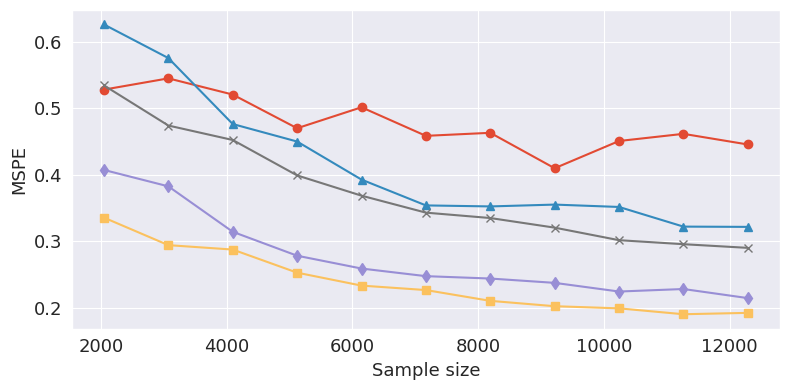

read file: res_nonlinear/fix_nn_n_t_FAR_v1_all.npz
image saved: res_nonlinear/plots_of_sequence_far_t.pdf


array([[0.52813376, 0.62621438, 0.4071635 , 0.53450597, 0.33534903],
       [0.54508227, 0.57563288, 0.38247195, 0.47404613, 0.29391626],
       [0.52067869, 0.47629493, 0.31402317, 0.45226116, 0.28727126],
       [0.46996434, 0.44994988, 0.27801267, 0.39895065, 0.25247547],
       [0.50153282, 0.39263025, 0.25870078, 0.36842911, 0.23300351],
       [0.45852203, 0.35375616, 0.24722796, 0.34286698, 0.22628699],
       [0.46309155, 0.35223414, 0.24364005, 0.33474429, 0.21003695],
       [0.40972994, 0.35499671, 0.23712555, 0.32027497, 0.20196513],
       [0.45076134, 0.35142346, 0.22406912, 0.30138448, 0.19873021],
       [0.46153586, 0.32183626, 0.22785563, 0.29535109, 0.18988139],
       [0.44551431, 0.3214268 , 0.21417959, 0.28983138, 0.19194356]])

In [10]:
plot_sequence("FAR_v1", condition="t")


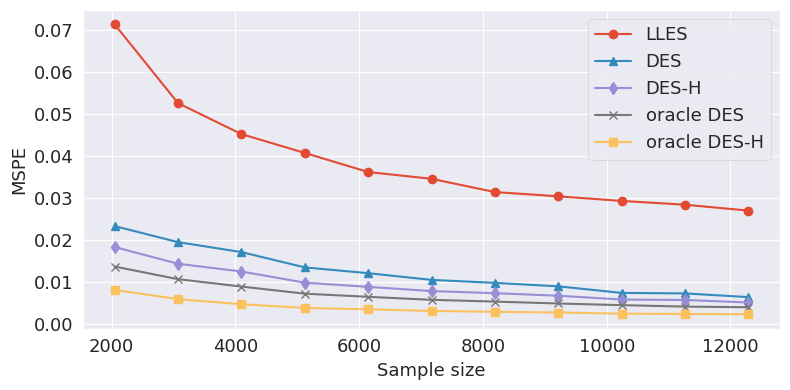

read file: res_nonlinear/fix_nn_n_normal_SIM_v1_all.npz
image saved: res_nonlinear/plots_of_sequence_sim_n.pdf


array([[0.07137549, 0.02329468, 0.0182876 , 0.01364175, 0.00806231],
       [0.05261014, 0.019461  , 0.01430785, 0.01063242, 0.00587421],
       [0.04523265, 0.01709359, 0.01246171, 0.00886757, 0.00465612],
       [0.04074041, 0.01344105, 0.00979611, 0.00717358, 0.00376087],
       [0.03618716, 0.01206204, 0.00880158, 0.00642295, 0.00344426],
       [0.03456769, 0.01046335, 0.00779852, 0.0057041 , 0.00305143],
       [0.03141224, 0.00974595, 0.00728344, 0.00528533, 0.00285253],
       [0.03039137, 0.00892275, 0.0066838 , 0.00482994, 0.00268151],
       [0.02929406, 0.00735611, 0.00577837, 0.00443817, 0.00240497],
       [0.0283935 , 0.00723395, 0.00566604, 0.00409162, 0.00233382],
       [0.0269843 , 0.00635478, 0.0050672 , 0.00393848, 0.00226938]])

In [11]:
plot_sequence("SIM_v1", condition="normal", legend = True)

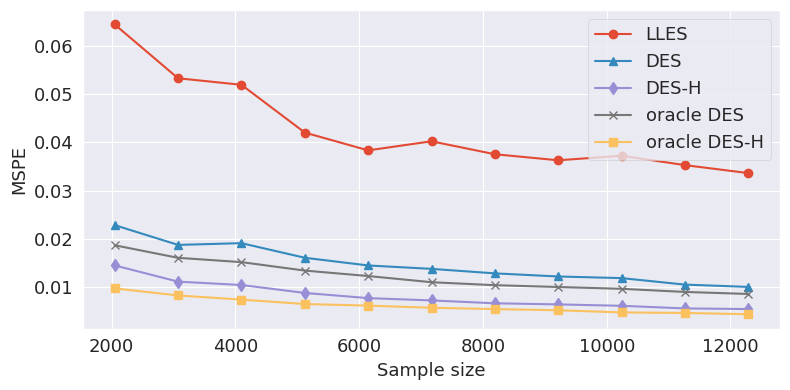

read file: res_nonlinear/fix_nn_n_t_SIM_v1_all.npz
image saved: res_nonlinear/plots_of_sequence_sim_t.pdf


array([[0.0644534 , 0.0228479 , 0.01449375, 0.01867822, 0.00973184],
       [0.05330359, 0.01875035, 0.01113797, 0.01607242, 0.00827056],
       [0.05194656, 0.01911361, 0.010438  , 0.01518217, 0.00740604],
       [0.0420444 , 0.01608341, 0.00879358, 0.01342601, 0.00649663],
       [0.03835402, 0.01448876, 0.00771546, 0.01229951, 0.00616218],
       [0.0402363 , 0.01378255, 0.00724191, 0.01101497, 0.00572205],
       [0.03754978, 0.01285066, 0.00664644, 0.01039988, 0.00544238],
       [0.03629794, 0.01220325, 0.00641635, 0.010023  , 0.00519857],
       [0.0372369 , 0.01186696, 0.00612489, 0.00964861, 0.0047541 ],
       [0.03529285, 0.01051905, 0.0055805 , 0.00899865, 0.00464267],
       [0.03363969, 0.01004251, 0.00545003, 0.00858107, 0.00437689]])

In [12]:
plot_sequence("SIM_v1", condition="t", legend = True)